In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
# =========================
# 1) DATA YÜKLE
# =========================
df = pd.read_csv("final_cleaned_dataset.csv")

In [3]:
print("\n=========================")
print("DATA LOADED")
print("=========================")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


DATA LOADED
    season  year           city  fulltimehomegoals  fulltimeawaygoals  \
0  2010/11  2010     birmingham                  3                  0   
1  2010/11  2010         london                  6                  0   
2  2010/11  2010     sunderland                  2                  2   
3  2010/11  2010         london                  0                  0   
4  2010/11  2010  wolverhampton                  2                  1   

  fulltimeresult  home_win  median_salary_gross_gbp_monthly  \
0              H         1                             1972   
1              H         1                             3285   
2              D         0                             2021   
3              D         0                             3285   
4              H         1                             2121   

   cost_of_living_index  affordability_ratio  rent_to_income_pct  \
0                  67.8                 1.39                27.9   
1                  95.6          

In [4]:
# =========================
# 2) GENEL BİLGİ
# =========================
print("\n=========================")
print("DATA OVERVIEW")
print("=========================")
print(df.info())


DATA OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   season                           1357 non-null   str    
 1   year                             1357 non-null   int64  
 2   city                             1357 non-null   str    
 3   fulltimehomegoals                1357 non-null   int64  
 4   fulltimeawaygoals                1357 non-null   int64  
 5   fulltimeresult                   1357 non-null   str    
 6   home_win                         1357 non-null   int64  
 7   median_salary_gross_gbp_monthly  1357 non-null   int64  
 8   cost_of_living_index             1357 non-null   float64
 9   affordability_ratio              1357 non-null   float64
 10  rent_to_income_pct               1357 non-null   float64
 11  region                           1357 non-null   str    
 12  population_appro

In [5]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
season                             0
year                               0
city                               0
fulltimehomegoals                  0
fulltimeawaygoals                  0
fulltimeresult                     0
home_win                           0
median_salary_gross_gbp_monthly    0
cost_of_living_index               0
affordability_ratio                0
rent_to_income_pct                 0
region                             0
population_approx                  0
real_wealth                        0
dtype: int64


In [6]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
              year  fulltimehomegoals  fulltimeawaygoals     home_win  \
count  1357.000000        1357.000000        1357.000000  1357.000000   
mean   2017.456153           1.769344           1.594694     0.428150   
std       4.300875           1.519976           1.404030     0.494993   
min    2010.000000           0.000000           0.000000     0.000000   
25%    2014.000000           1.000000           0.000000     0.000000   
50%    2018.000000           2.000000           1.000000     0.000000   
75%    2021.000000           3.000000           2.000000     1.000000   
max    2024.000000           9.000000           9.000000     1.000000   

       median_salary_gross_gbp_monthly  cost_of_living_index  \
count                      1357.000000           1357.000000   
mean                       2725.235077             75.766028   
std                         655.760906             13.926752   
min                        1907.000000             56.100000 

In [7]:
# =========================
# 3) SONUÇ DAĞILIMI
# =========================
print("\n=========================")
print("MATCH RESULT DISTRIBUTION")
print("=========================")
print(df["fulltimeresult"].value_counts())


MATCH RESULT DISTRIBUTION
fulltimeresult
H    581
A    502
D    274
Name: count, dtype: int64


In [8]:
print("\nHome win distribution:")
print(df["home_win"].value_counts())


Home win distribution:
home_win
0    776
1    581
Name: count, dtype: int64


In [9]:
overall_home_win = df["home_win"].mean()
print("\nOverall home win rate:", overall_home_win)


Overall home win rate: 0.4281503316138541


In [10]:
# =========================
# 4) ŞEHİR BAZLI ANALİZ
# =========================
print("\n=========================")
print("CITY-LEVEL HOME WIN RATE")
print("=========================")
city_home_win = df.groupby("city")["home_win"].mean().sort_values(ascending=False)
print(city_home_win)


CITY-LEVEL HOME WIN RATE
city
liverpool        0.543210
london           0.485955
birmingham       0.398601
leeds            0.378378
bournemouth      0.376238
wolverhampton    0.371134
brighton         0.369565
southampton      0.359155
sunderland       0.345679
blackpool        0.333333
middlesbrough    0.300000
sheffield        0.272727
reading          0.230769
Name: home_win, dtype: float64


In [11]:
print("\n=========================")
print("CITY-LEVEL HOME GOALS")
print("=========================")
city_home_goals = df.groupby("city")["fulltimehomegoals"].mean().sort_values(ascending=False)
print(city_home_goals)


CITY-LEVEL HOME GOALS
city
london           2.188202
liverpool        2.127572
blackpool        1.777778
birmingham       1.580420
brighton         1.500000
leeds            1.486486
southampton      1.485915
reading          1.461538
bournemouth      1.455446
wolverhampton    1.402062
sunderland       1.345679
sheffield        1.121212
middlesbrough    1.100000
Name: fulltimehomegoals, dtype: float64


In [12]:
# =========================
# 5) WEALTH ANALYSIS
# =========================
print("\n=========================")
print("WEALTH VARIABLES")
print("=========================")
wealth_cols = ["real_wealth", "affordability_ratio", "rent_to_income_pct"]
print(df[wealth_cols].describe())


WEALTH VARIABLES
       real_wealth  affordability_ratio  rent_to_income_pct
count  1357.000000          1357.000000         1357.000000
mean     35.758802             1.321614           31.402063
std       3.640937             0.094585            4.912798
min      29.085546             1.090000           21.500000
25%      33.010130             1.260000           28.000000
50%      35.237500             1.310000           29.800000
75%      37.685185             1.380000           36.200000
max      47.748148             1.680000           44.500000


In [13]:
print("\n=========================")
print("CORRELATION MATRIX")
print("=========================")
corr_matrix = df[
    [
        "real_wealth",
        "affordability_ratio",
        "rent_to_income_pct",
        "fulltimehomegoals",
        "fulltimeawaygoals",
        "home_win"
    ]
].corr()


CORRELATION MATRIX


In [14]:
print(corr_matrix)

                     real_wealth  affordability_ratio  rent_to_income_pct  \
real_wealth             1.000000            -0.208368            0.320813   
affordability_ratio    -0.208368             1.000000           -0.837441   
rent_to_income_pct      0.320813            -0.837441            1.000000   
fulltimehomegoals       0.034890            -0.147141            0.172921   
fulltimeawaygoals       0.067894            -0.034165            0.063917   
home_win                0.014021            -0.085178            0.080606   

                     fulltimehomegoals  fulltimeawaygoals  home_win  
real_wealth                   0.034890           0.067894  0.014021  
affordability_ratio          -0.147141          -0.034165 -0.085178  
rent_to_income_pct            0.172921           0.063917  0.080606  
fulltimehomegoals             1.000000          -0.143015  0.670452  
fulltimeawaygoals            -0.143015           1.000000 -0.517315  
home_win                      0.670452  

In [15]:
# =========================
# 6) HYPOTHESIS TESTS
# =========================
print("\n=========================")
print("HYPOTHESIS TEST 1")
print("real_wealth vs home_win")
print("=========================")
corr1, p1 = pearsonr(df["real_wealth"], df["home_win"])
print("Correlation:", corr1)
print("P-value:", p1)


HYPOTHESIS TEST 1
real_wealth vs home_win
Correlation: 0.014020542018621417
P-value: 0.6058328604587764


In [16]:
if p1 < 0.05:
    print("Result: Statistically significant relationship.")
else:
    print("Result: Not statistically significant.")

Result: Not statistically significant.


In [17]:
print("\n=========================")
print("HYPOTHESIS TEST 2")
print("real_wealth vs fulltimehomegoals")
print("=========================")
corr2, p2 = pearsonr(df["real_wealth"], df["fulltimehomegoals"])
print("Correlation:", corr2)
print("P-value:", p2)


HYPOTHESIS TEST 2
real_wealth vs fulltimehomegoals
Correlation: 0.03489024125167932
P-value: 0.19897572171528227


In [18]:
if p2 < 0.05:
    print("Result: Statistically significant relationship.")
else:
    print("Result: Not statistically significant.")

Result: Not statistically significant.


In [19]:
# =========================
# 7) CITY SUMMARY TABLE
# =========================
print("\n=========================")
print("CITY SUMMARY")
print("=========================")
city_summary = df.groupby("city").agg(
    matches=("home_win", "count"),
    avg_home_win=("home_win", "mean"),
    avg_home_goals=("fulltimehomegoals", "mean"),
    avg_real_wealth=("real_wealth", "mean"),
    avg_affordability=("affordability_ratio", "mean"),
    avg_rent_to_income=("rent_to_income_pct", "mean")
).sort_values(by="avg_home_win", ascending=False)


CITY SUMMARY


In [20]:
print(city_summary)

               matches  avg_home_win  avg_home_goals  avg_real_wealth  \
city                                                                    
liverpool          243      0.543210        2.127572        35.114728   
london             356      0.485955        2.188202        37.730955   
birmingham         143      0.398601        1.580420        33.105219   
leeds               37      0.378378        1.486486        37.277033   
bournemouth        101      0.376238        1.455446        35.450905   
wolverhampton       97      0.371134        1.402062        39.465282   
brighton            92      0.369565        1.500000        33.437033   
southampton        142      0.359155        1.485915        34.742725   
sunderland          81      0.345679        1.345679        32.926881   
blackpool            9      0.333333        1.777778        37.397504   
middlesbrough       10      0.300000        1.100000        36.056338   
sheffield           33      0.272727        1.12121

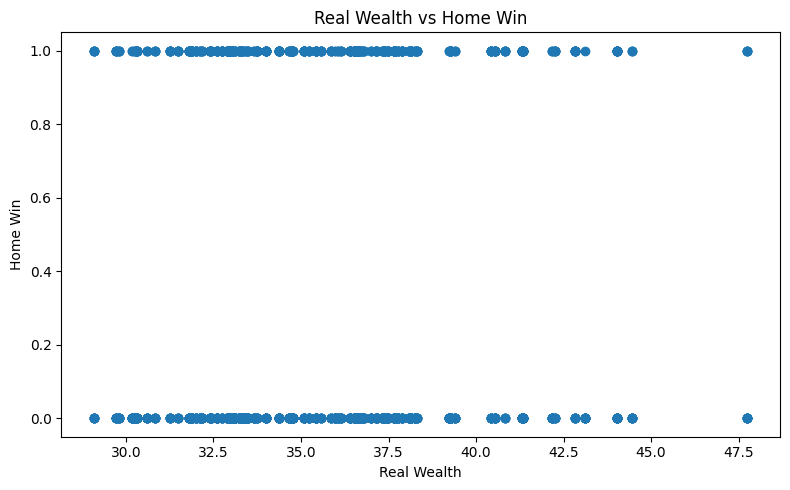

In [21]:
# =========================
# 8) GRAFİKLER
# =========================
plt.figure(figsize=(8, 5))
plt.scatter(df["real_wealth"], df["home_win"])
plt.xlabel("Real Wealth")
plt.ylabel("Home Win")
plt.title("Real Wealth vs Home Win")
plt.tight_layout()
plt.savefig("plot_real_wealth_vs_home_win.png")
plt.show()

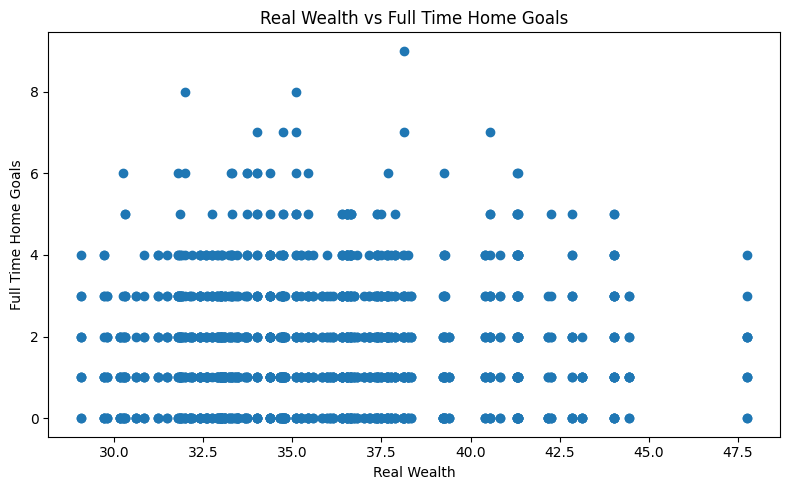

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df["real_wealth"], df["fulltimehomegoals"])
plt.xlabel("Real Wealth")
plt.ylabel("Full Time Home Goals")
plt.title("Real Wealth vs Full Time Home Goals")
plt.tight_layout()
plt.savefig("plot_real_wealth_vs_home_goals.png")
plt.show()

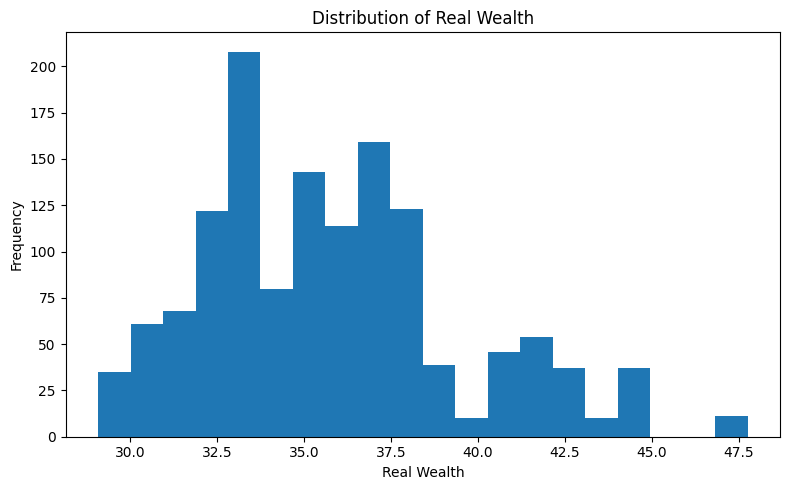

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df["real_wealth"], bins=20)
plt.xlabel("Real Wealth")
plt.ylabel("Frequency")
plt.title("Distribution of Real Wealth")
plt.tight_layout()
plt.savefig("plot_real_wealth_distribution.png")
plt.show()

In [24]:
# =========================
# 9) OPTIONAL: CSV OUTPUT
# =========================
city_summary.to_csv("city_summary.csv")

In [25]:
print("\n=========================")
print("FILES CREATED")
print("=========================")
print("1) plot_real_wealth_vs_home_win.png")
print("2) plot_real_wealth_vs_home_goals.png")
print("3) plot_real_wealth_distribution.png")
print("4) city_summary.csv")


FILES CREATED
1) plot_real_wealth_vs_home_win.png
2) plot_real_wealth_vs_home_goals.png
3) plot_real_wealth_distribution.png
4) city_summary.csv
